Linear: 0.7347215072460884
Ridge : 0.7361142564746577
Lasso : 0.7907657914398227


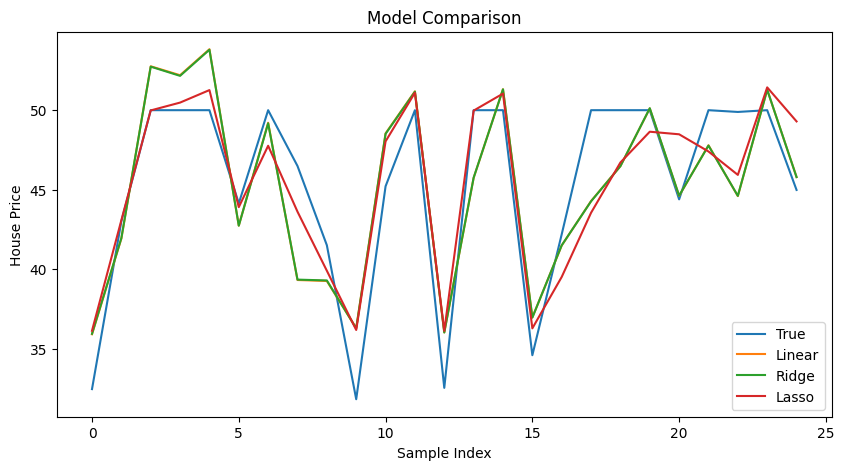

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score

# 一、读取数据
df = pd.read_csv('boston_housing.csv')

# 二、划分特征和标签（推荐写法，更稳）
X = df.drop('MEDV', axis=1)   # 特征
y = df['MEDV']                # 房价

# 三、划分训练集和测试集
X_train = X.iloc[:481]
y_train = y.iloc[:481]

X_test = X.iloc[481:]
y_test = y.iloc[481:]

# 四、创建模型
line = LinearRegression()
ridge = Ridge()
lasso = Lasso(max_iter=10000)   # 防止不收敛

# 五、训练模型
line.fit(X_train, y_train)
ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)

# 六、预测
line_y_pre = line.predict(X_test)
ridge_y_pre = ridge.predict(X_test)
lasso_y_pre = lasso.predict(X_test)

# 七、计算 R² 分数
line_score = r2_score(y_test, line_y_pre)
ridge_score = r2_score(y_test, ridge_y_pre)
lasso_score = r2_score(y_test, lasso_y_pre)

print("Linear:", line_score)
print("Ridge :", ridge_score)
print("Lasso :", lasso_score)

# 八、画图对比
plt.figure(figsize=(10, 5))

plt.plot(y_test.to_numpy(), label='True')     # 真实值
plt.plot(line_y_pre, label='Linear')          # 线性回归
plt.plot(ridge_y_pre, label='Ridge')          # 岭回归
plt.plot(lasso_y_pre, label='Lasso')          # Lasso回归

plt.legend()
plt.title('Model Comparison')
plt.xlabel('Sample Index')
plt.ylabel('House Price')

plt.show()